# Sales Performance Analysis
Retail sales case study using Python, Pandas, and Matplotlib

## Business Objective
The goal of this project is to analyze retail sales performance across time, geography, customer segments, products, and shipping methods to identify business insights and improvement opportunities.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
df_raw = pd.read_csv("../data/sales.csv")
df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Initial Inspection
df_raw.info()
df_raw.isna().sum().sort_values(ascending=False)
df_raw.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

np.int64(0)

In [4]:
# Data Cleaning
df_clean = df_raw.copy()

df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"], dayfirst=True, errors="coerce")
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"], dayfirst=True, errors="coerce")
df_clean["Sales"] = pd.to_numeric(df_clean["Sales"], errors="coerce")

df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna(subset=["Order Date", "Sales", "Region", "Category"])

In [5]:
# Feature Engineering
df_clean["Order Year"] = df_clean["Order Date"].dt.year
df_clean["Order Month"] = df_clean["Order Date"].dt.month
df_clean["Order Month Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Year-Month"] = df_clean["Order Date"].dt.to_period("M").astype(str)

df_clean["Shipping Delay Days"] = (
    df_clean["Ship Date"] - df_clean["Order Date"]
).dt.days

In [6]:
## Cleaned Dataset Preview
df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row ID               9800 non-null   int64         
 1   Order ID             9800 non-null   object        
 2   Order Date           9800 non-null   datetime64[ns]
 3   Ship Date            9800 non-null   datetime64[ns]
 4   Ship Mode            9800 non-null   object        
 5   Customer ID          9800 non-null   object        
 6   Customer Name        9800 non-null   object        
 7   Segment              9800 non-null   object        
 8   Country              9800 non-null   object        
 9   City                 9800 non-null   object        
 10  State                9800 non-null   object        
 11  Postal Code          9789 non-null   float64       
 12  Region               9800 non-null   object        
 13  Product ID           9800 non-nul

In [7]:
## KPI Summary
total_sales = df_clean["Sales"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()
average_sales_per_order = total_sales / total_orders

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Sales per Order: ${average_sales_per_order:,.2f}")

Total Sales: $2,261,536.78
Total Orders: 4,922
Total Customers: 793
Average Sales per Order: $459.48


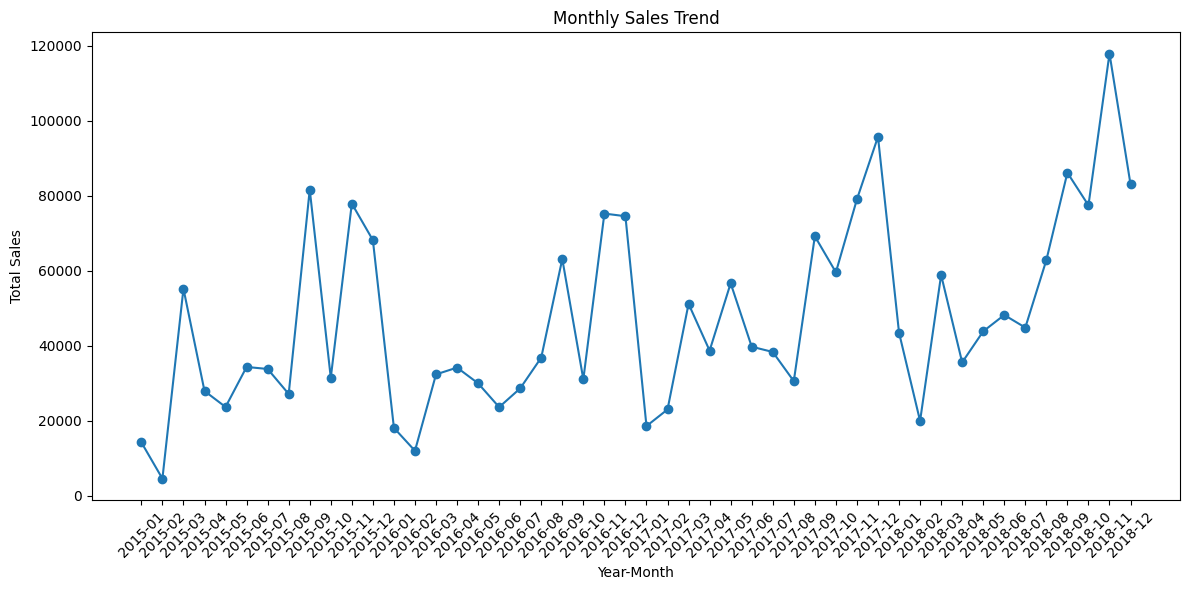

In [8]:
## Time Analysis
### Monthly Sales Trend
monthly_sales = (
    df_clean.groupby("Year-Month")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["Year-Month"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")
plt.show()

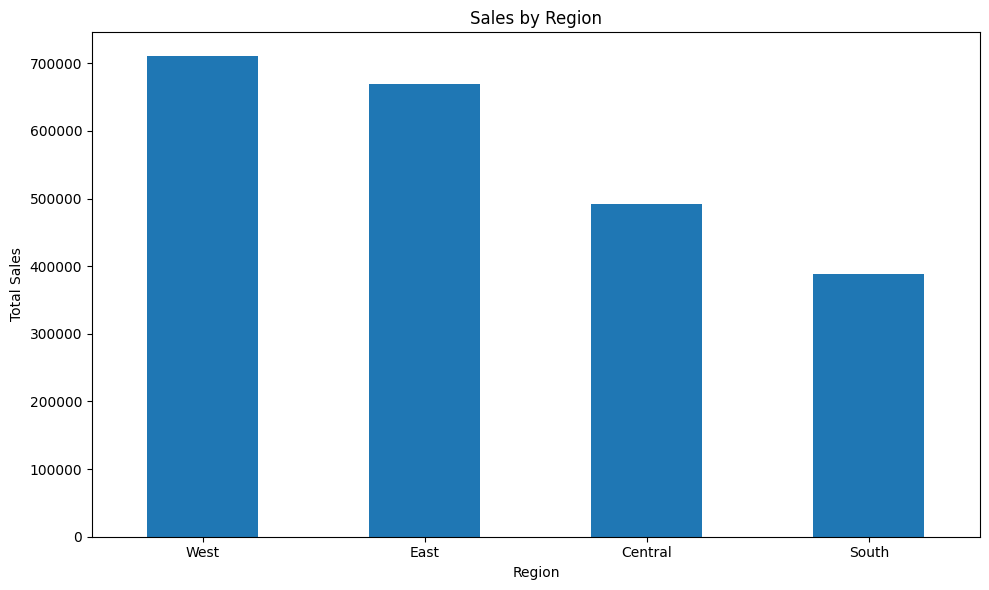

In [9]:
## Regional Analysis
### Sales by Region
sales_by_region = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sales_by_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

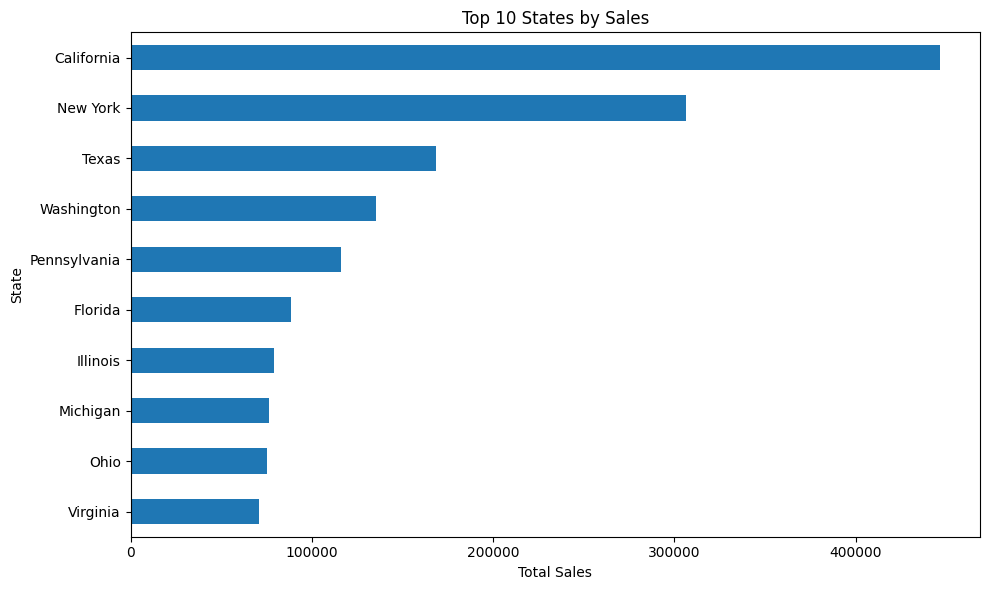

In [10]:
### Top 10 States by Sales
top_states = (
    df_clean.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_states.sort_values().plot(kind="barh")
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("../images/top_10_states.png", dpi=300, bbox_inches="tight")
plt.show()

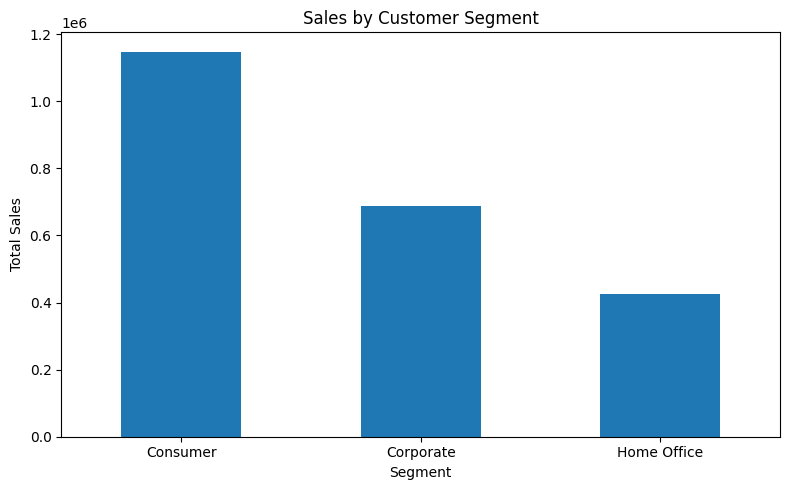

In [11]:
## Customer Analysis
### Sales by Customer Segment
sales_by_segment = (
    df_clean.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sales_by_segment.plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/sales_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

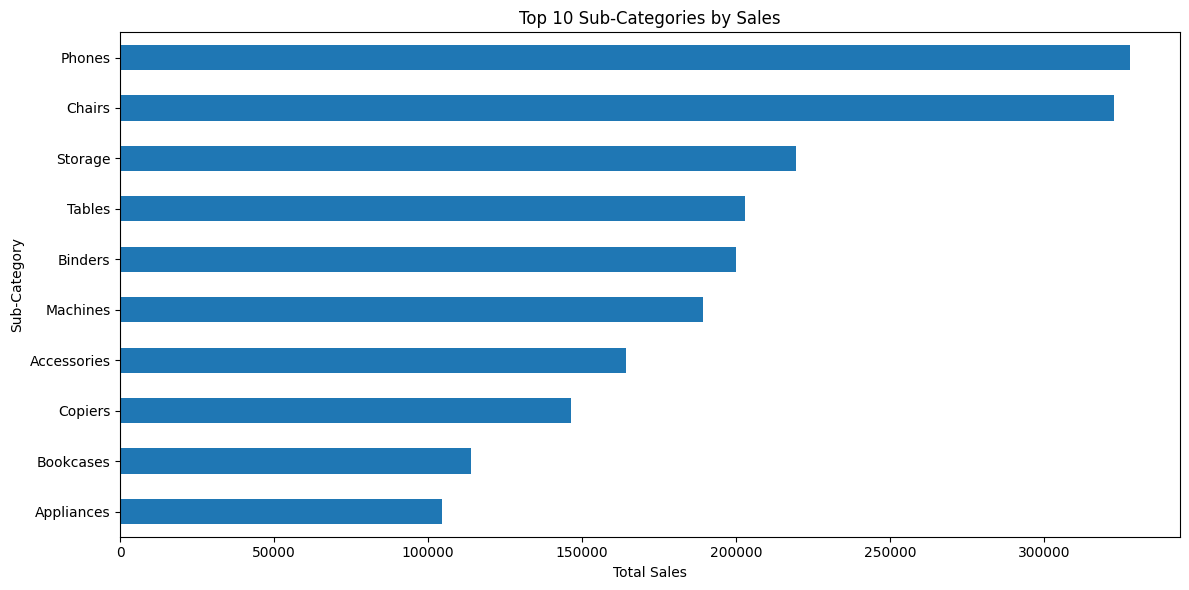

In [12]:
## Product Analysis
### Top 10 Sub-Categories by Sales
sales_by_subcategory = (
    df_clean.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sales_by_subcategory.sort_values().plot(kind="barh")
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.savefig("../images/top_10_subcategories.png", dpi=300, bbox_inches="tight")
plt.show()


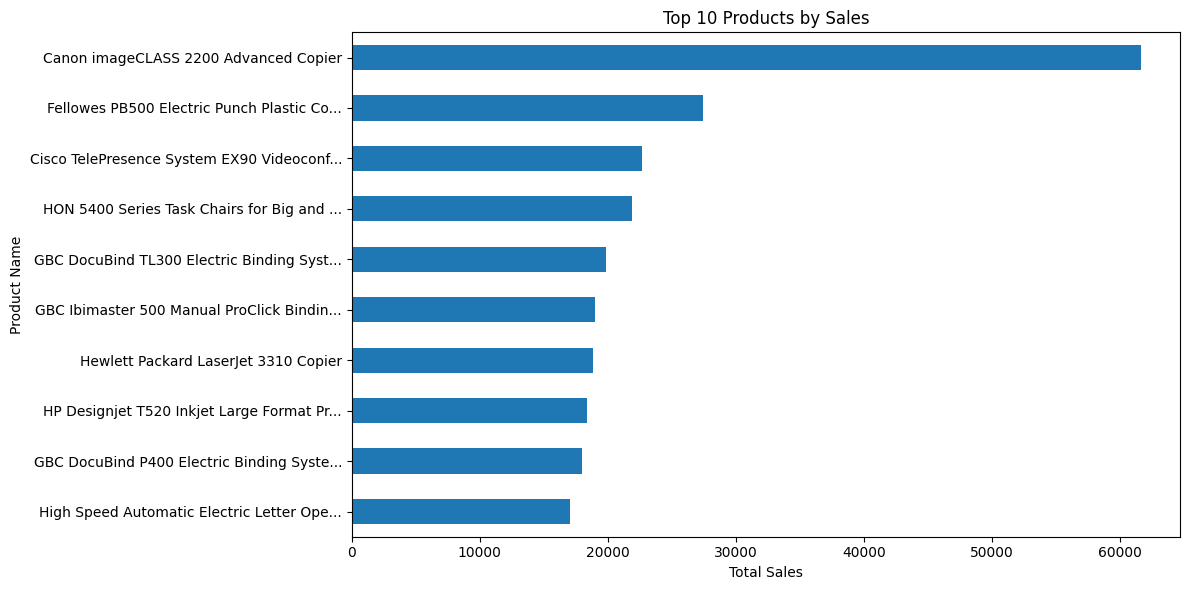

In [13]:
### Top 10 Products by Sales
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_short = top_products.copy()
top_products_short.index = [
    name[:40] + "..." if len(name) > 40 else name
    for name in top_products_short.index
]

plt.figure(figsize=(12, 6))
top_products_short.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.savefig("../images/top_10_products.png", dpi=300, bbox_inches="tight")
plt.show()

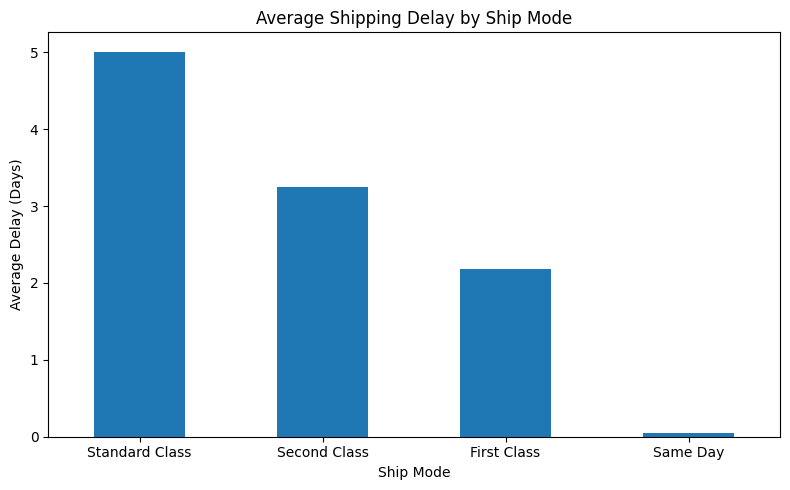

In [14]:
## Shipping Analysis
### Average Shipping Delay by Ship Mode
shipping_delay_by_mode = (
    df_clean.groupby("Ship Mode")["Shipping Delay Days"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
shipping_delay_by_mode.plot(kind="bar")
plt.title("Average Shipping Delay by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/shipping_delay_by_mode.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Findings
- Revenue reached $872K+ across 1,975 orders from 736 customers.
- Sales were concentrated in a few strong-performing regions and states.
- A small number of products and sub-categories drove a large share of revenue.
- Customer segments showed different levels of contribution to total sales.
- Shipping performance followed expected patterns, with Same Day being fastest and Standard Class taking longer.

## Recommendations
- Prioritize inventory and promotions in top-performing regions and states.
- Focus campaigns on best-selling products and sub-categories.
- Review weaker-performing locations for growth opportunities.
- Use shipping strategy more selectively for high-value orders.

In [15]:
## Save Cleaned Dataset
df_clean.to_csv("../data/sales_cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
